# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [22]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [23]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [24]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


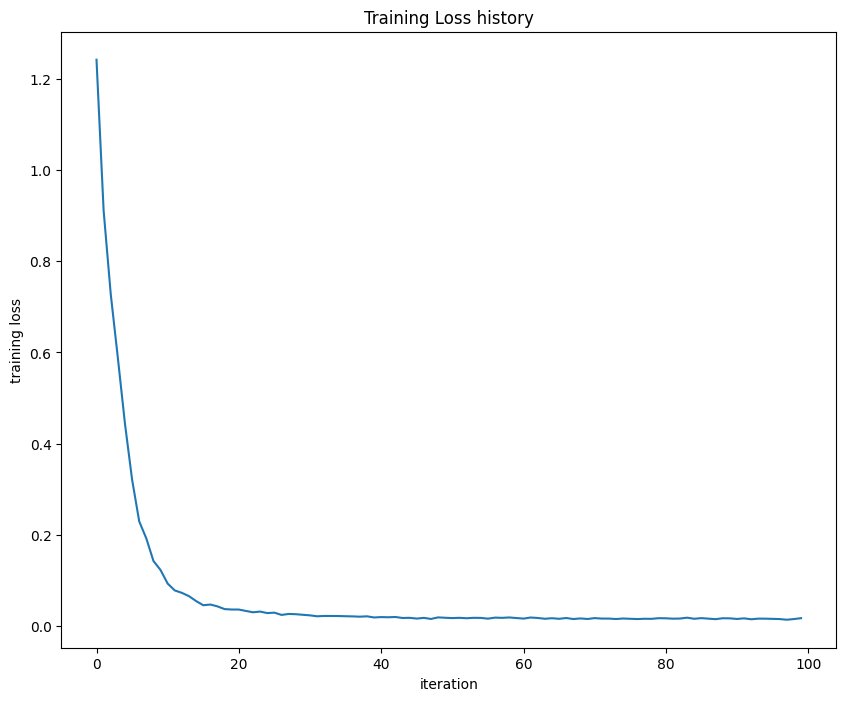

In [25]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [2]:
from scripts.data_utils import load_CIFAR10

cifar10_dir = 'cifar-10-batches-py'
X_train_full, y_train_full, X_test_full, y_test_full = load_CIFAR10(cifar10_dir)

print('Full train data shape: ', X_train_full.shape)
print('Full train labels shape: ', y_train_full.shape)
print('Full test data shape: ', X_test_full.shape)
print('Full test labels shape: ', y_test_full.shape)

/workspaces/AIT_Labs_6401_SurkovaAS/lab_1-2/scripts/data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Full train data shape:  (50000, 32, 32, 3)
Full train labels shape:  (50000,)
Full test data shape:  (10000, 32, 32, 3)
Full test labels shape:  (10000,)


In [6]:
train_count = 49000
val_count = 1000
test_count = 1000
dev_count = 500

validation_indices = list(range(train_count, train_count + val_count))
X_val = X_train_full[validation_indices]
y_val = y_train_full[validation_indices]

train_indices = list(range(train_count))
X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]

dev_indices = np.random.choice(train_count, dev_count, replace=False)
X_dev = X_train[dev_indices]
y_dev = y_train[dev_indices]

test_indices = list(range(test_count))
X_test = X_test_full[test_indices]
y_test = y_test_full[test_indices]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)
Dev data shape:  (500, 32, 32, 3)
Dev labels shape:  (500,)


In [7]:
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

mean_image = np.mean(X_train, axis=0)

X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image
X_dev = X_dev - mean_image

print('Shapes after preprocessing:')
print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)
print('Dev:', X_dev.shape)

Shapes after preprocessing:
Train: (49000, 3072)
Validation: (1000, 3072)
Test: (1000, 3072)
Dev: (500, 3072)


In [8]:
input_size = 32 * 32 * 3
hidden_size = 100
num_classes = 10

net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(
    X_train, y_train, X_val, y_val,
    num_iters=1000,
    batch_size=200,
    learning_rate=1e-3,
    learning_rate_decay=0.95,
    reg=1e-4,
    verbose=True
)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302556
iteration 100 / 1000: loss 1.953546
iteration 200 / 1000: loss 1.809992
iteration 300 / 1000: loss 1.675770
iteration 400 / 1000: loss 1.626797
iteration 500 / 1000: loss 1.687348
iteration 600 / 1000: loss 1.603570
iteration 700 / 1000: loss 1.408939
iteration 800 / 1000: loss 1.523852
iteration 900 / 1000: loss 1.422803
Validation accuracy:  0.485


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

In [5]:
best_net = None
best_val_acc = -1
best_stats = None

hidden_sizes = [200, 250]
learning_rates = [1e-3, 5e-4]
regularization_strengths = [5e-5, 1e-4]
decay_values = [0.95, 0.97]
batch_sizes = [200]
iteration_values = [2500, 3000]

results = {}

train_size = X_train.shape[0]

for current_hidden_size in hidden_sizes:
    for current_learning_rate in learning_rates:
        for current_reg in regularization_strengths:
            for current_decay in decay_values:
                for current_batch_size in batch_sizes:
                    for current_num_iters in iteration_values:
                        current_epochs = current_num_iters * current_batch_size / train_size

                        current_net = TwoLayerNet(32 * 32 * 3, current_hidden_size, 10)

                        current_stats = current_net.train(
                            X_train, y_train, X_val, y_val,
                            num_iters=current_num_iters,
                            batch_size=current_batch_size,
                            learning_rate=current_learning_rate,
                            learning_rate_decay=current_decay,
                            reg=current_reg,
                            verbose=False
                        )

                        current_train_acc = (current_net.predict(X_train) == y_train).mean()
                        current_val_acc = (current_net.predict(X_val) == y_val).mean()

                        results[(
                            current_hidden_size,
                            current_learning_rate,
                            current_reg,
                            current_decay,
                            current_batch_size,
                            current_num_iters
                        )] = (
                            current_train_acc,
                            current_val_acc,
                            current_epochs
                        )

                        if current_val_acc > best_val_acc:
                            best_val_acc = current_val_acc
                            best_net = current_net
                            best_stats = current_stats

In [8]:
for params, scores in results.items():
    (
        hidden_size_value,
        lr_value,
        reg_value,
        decay_value,
        batch_size_value,
        num_iters_value
    ) = params

    train_acc_value, val_acc_value, epochs_value = scores

    print(
        'hidden = %d, lr = %e, reg = %e, decay = %.2f, batch = %d, iters = %d, epochs = %.2f, train acc = %f, val acc = %f'
        % (
            hidden_size_value,
            lr_value,
            reg_value,
            decay_value,
            batch_size_value,
            num_iters_value,
            epochs_value,
            train_acc_value,
            val_acc_value
        )
    )

print('Best validation accuracy: ', best_val_acc)

hidden = 200, lr = 1.000000e-03, reg = 5.000000e-05, decay = 0.95, batch = 200, iters = 2500, epochs = 10.20, train acc = 0.606408, val acc = 0.532000
hidden = 200, lr = 1.000000e-03, reg = 5.000000e-05, decay = 0.95, batch = 200, iters = 3000, epochs = 12.24, train acc = 0.624796, val acc = 0.551000
hidden = 200, lr = 1.000000e-03, reg = 5.000000e-05, decay = 0.97, batch = 200, iters = 2500, epochs = 10.20, train acc = 0.597367, val acc = 0.527000
hidden = 200, lr = 1.000000e-03, reg = 5.000000e-05, decay = 0.97, batch = 200, iters = 3000, epochs = 12.24, train acc = 0.620224, val acc = 0.515000
hidden = 200, lr = 1.000000e-03, reg = 1.000000e-04, decay = 0.95, batch = 200, iters = 2500, epochs = 10.20, train acc = 0.606633, val acc = 0.526000
hidden = 200, lr = 1.000000e-03, reg = 1.000000e-04, decay = 0.95, batch = 200, iters = 3000, epochs = 12.24, train acc = 0.626184, val acc = 0.552000
hidden = 200, lr = 1.000000e-03, reg = 1.000000e-04, decay = 0.97, batch = 200, iters = 2500, 

In [9]:
test_accuracy = (best_net.predict(X_test) == y_test).mean()
print('Test accuracy: ', test_accuracy)

Test accuracy:  0.529


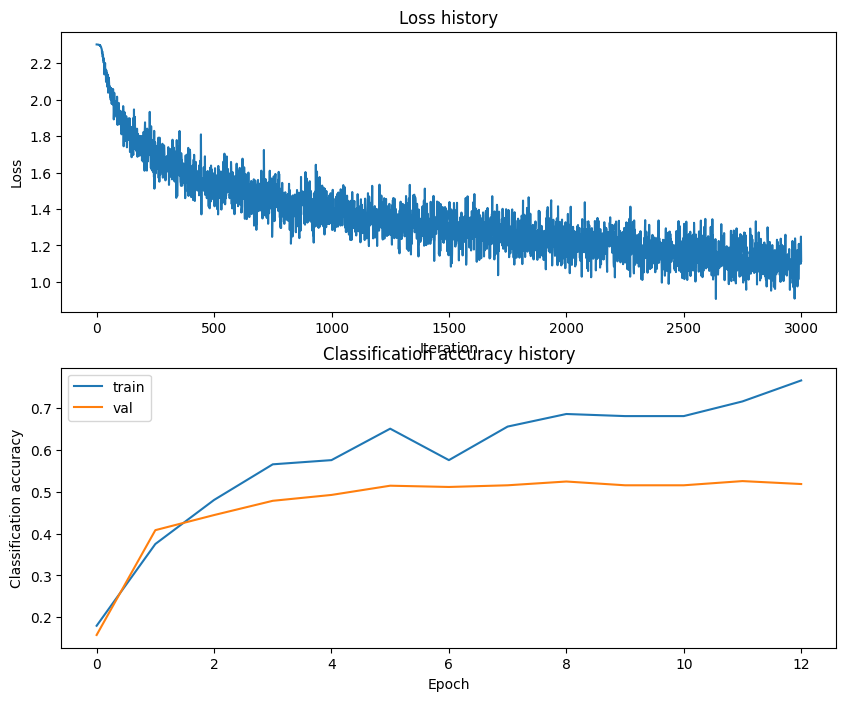

In [10]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

In [10]:
best_net = None
best_val_acc = -1
best_stats = None

hidden_sizes = [200, 250]
learning_rates = [5e-3, 1e-3, 7e-4]
regularization_strengths =  [1e-3, 5e-3, 1e-2]
decay_values = [0.95, 0.92, 0.9]
batch_sizes = [200]
iteration_values = [2500, 3000]

results = {}

train_size = X_train.shape[0]

for current_hidden_size in hidden_sizes:
    for current_learning_rate in learning_rates:
        for current_reg in regularization_strengths:
            for current_decay in decay_values:
                for current_batch_size in batch_sizes:
                    for current_num_iters in iteration_values:
                        current_epochs = current_num_iters * current_batch_size / train_size

                        current_net = TwoLayerNet(32 * 32 * 3, current_hidden_size, 10)

                        current_stats = current_net.train(
                            X_train, y_train, X_val, y_val,
                            num_iters=current_num_iters,
                            batch_size=current_batch_size,
                            learning_rate=current_learning_rate,
                            learning_rate_decay=current_decay,
                            reg=current_reg,
                            verbose=False
                        )

                        current_train_acc = (current_net.predict(X_train) == y_train).mean()
                        current_val_acc = (current_net.predict(X_val) == y_val).mean()

                        results[(
                            current_hidden_size,
                            current_learning_rate,
                            current_reg,
                            current_decay,
                            current_batch_size,
                            current_num_iters
                        )] = (
                            current_train_acc,
                            current_val_acc,
                            current_epochs
                        )

                        if current_val_acc > best_val_acc:
                            best_val_acc = current_val_acc
                            best_net = current_net
                            best_stats = current_stats

In [13]:
for params, scores in results.items():
    (
        hidden_size_value,
        lr_value,
        reg_value,
        decay_value,
        batch_size_value,
        num_iters_value
    ) = params

    train_acc_value, val_acc_value, epochs_value = scores

    print(
        'hidden = %d, lr = %e, reg = %e, decay = %.2f, batch = %d, iters = %d, epochs = %.2f, train acc = %f, val acc = %f'
        % (
            hidden_size_value,
            lr_value,
            reg_value,
            decay_value,
            batch_size_value,
            num_iters_value,
            epochs_value,
            train_acc_value,
            val_acc_value
        )
    )

print('Best validation accuracy: ', best_val_acc)

hidden = 200, lr = 5.000000e-03, reg = 1.000000e-03, decay = 0.95, batch = 200, iters = 2500, epochs = 10.20, train acc = 0.100265, val acc = 0.087000
hidden = 200, lr = 5.000000e-03, reg = 1.000000e-03, decay = 0.95, batch = 200, iters = 3000, epochs = 12.24, train acc = 0.100265, val acc = 0.087000
hidden = 200, lr = 5.000000e-03, reg = 1.000000e-03, decay = 0.92, batch = 200, iters = 2500, epochs = 10.20, train acc = 0.100265, val acc = 0.087000
hidden = 200, lr = 5.000000e-03, reg = 1.000000e-03, decay = 0.92, batch = 200, iters = 3000, epochs = 12.24, train acc = 0.100265, val acc = 0.087000
hidden = 200, lr = 5.000000e-03, reg = 1.000000e-03, decay = 0.90, batch = 200, iters = 2500, epochs = 10.20, train acc = 0.277633, val acc = 0.255000
hidden = 200, lr = 5.000000e-03, reg = 1.000000e-03, decay = 0.90, batch = 200, iters = 3000, epochs = 12.24, train acc = 0.357265, val acc = 0.314000
hidden = 200, lr = 5.000000e-03, reg = 5.000000e-03, decay = 0.95, batch = 200, iters = 2500, 

In [12]:
test_accuracy = (best_net.predict(X_test) == y_test).mean()
print('Test accuracy: ', test_accuracy)

Test accuracy:  0.534


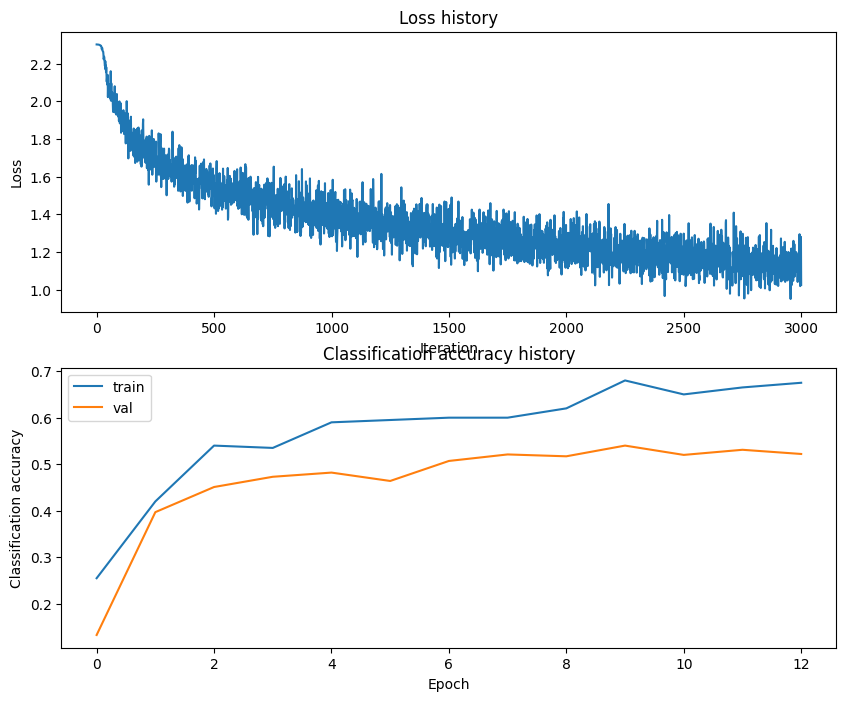

In [14]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

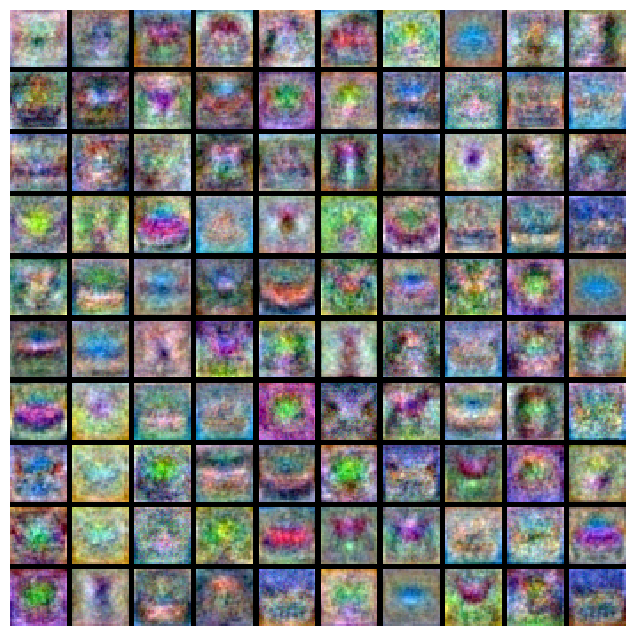

In [ ]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

Сделайте выводы по результатам работы. 

В работе была корректно реализована двухслойная полносвязная нейронная сеть, значения выхода и функции потерь прямого прохода, разница значений переменных обратного и прямого подхода максимально совпадают с эталонными (в рамках требуемых погрешностей). Функция потерь убывает. До подбора гиперпараметров точность данной модели на валидационной выборке - 0.48.

Далее согласно заданию проведён подбор гиперпараметров для повышения точности. В ходе 2 экспериментов изменялись: 
- размер скрытого слоя hidden 200, 250 (пробуем увеличить количество нейронов, чтобы лучше запоминались признаки), 
- скорость обучения learning rate 1e-4, 5e-4, 1e-3, 5e-3, 1e-2 (увеличиваем постепенно, чтобы долго не задерживаться на редких значениях и переходить дальше, но не слишком быстро, чтобы не loss не начал колебаться или расходиться, не было всплесков потерь),
- коэффициент регуляризации reg = 1e-4, 5e-5, 1e-3, 5e-3, 1e-2 (пробуем увеличивать, чтобы снизить переобучение, но не сильно, иначе увеличим обобщение, недообучим модель и получим точность ниже), 
- коэффициент затухания скорости обучения decay = 0.9, 0.92, 0.95, 0.97 (уменьшаем, чтобы заканчивать обучение быстрее и уменьшать переобучение модели особенно на поздних эпохах),
- количество эпох до 12 примерно, зависящее от количество итераций num_iters от 2000 до 3000 и размера батча batch_size 200, 250 
(увеличение этих 2 параметров больше не требуется, так как при увеличении 1 вырастет только точность на обучающих данных, модель лучше запомнит их, но это никак не повлияет или даже чуть уменьшит точность на валидационных, а увеличение 2 - даст более гладкий градиент, ухудшит обобщение опять же за счет запоминания большего числа обучающих данных, при увеличении обоих также есть риск переобучения, лучше работать с предыдущими гиперпараметрами). 

Для каждой конфигурации вычислялась точность на обучающей и валидационной выборках, лучший набор гиперпараметров, давший максимальное значение validation accuracy = 0.55 и test accuracy = 0.53: hidden = 200, lr = 1e-3, reg = 1e-4, decay = 0.95, batch_size = 200, num_iters = 3000.